<a href="https://colab.research.google.com/github/rista-laria/Cascade-Classifier-Cascade-Classifier-Training/blob/main/Pertemuan%205/5.1%20train-yolov8-object-detection-on-custom-dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1 Train Yolo V8 using Pytorch & Ultralytics Framework
- Setting GPU Environment
- Installing Ultralytics YOLOv8 on Colab
- Download Dataset from Roboflow (previous notebook)
- Train Custom YOLOv8 Detector
- Infer Custom Objects with Saved YOLOv8 (`.pt`)

⚠️⚠️⚠️ *Please open this notebook in Google Colab* by click below link ⚠️⚠️⚠️<br><br>
<a href="https://colab.research.google.com/github/Muhammad-Yunus/Belajar-OpenCV-ObjectDetection/blob/main/Pertemuan%205/5.1 train-yolov8-object-detection-on-custom-dataset.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1.1 Connect GPU Environment

- Click `Connect` button in top right Google Colab notebook,<br>
<img src="https://github.com/Muhammad-Yunus/Belajar-OpenCV-ObjectDetection/blob/main/Pertemuan%205/resource/cl-connect-gpu.png?raw=1" width="250px">
- If connecting process completed, it will turn to something look like this<br>
<img src="https://github.com/Muhammad-Yunus/Belajar-OpenCV-ObjectDetection/blob/main/Pertemuan%205/resource/cl-connect-gpu-success.png?raw=1" width="250px">

- Check GPU connected into Colab environment is active

In [3]:
!pip install torch==2.5.1 torchvision==0.20.1 numpy==1.26.4 ultralytics==8.0.196 --force-reinstall

  Using cached torch-2.5.1-cp312-cp312-manylinux1_x86_64.whl.metadata (28 kB)
  Using cached torchvision-0.20.1-cp312-cp312-manylinux1_x86_64.whl.metadata (6.1 kB)
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached ultralytics-8.0.196-py3-none-any.whl.metadata (31 kB)
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.3.0-py3-none-any.whl.metadata (10 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu

In [1]:
import torch
print(torch.__version__)

2.5.1+cu124


In [2]:
import numpy as np
print(np.__version__)

1.26.4


In [3]:
!nvidia-smi

Tue Apr 21 10:35:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
import os
HOME = os.getcwd()
print(HOME)

/content


## 1.2 Installing Ultralytics YOLOv8 on Colab
- `Ultralytics YOLO` is python library that help simplify YOLO training model in `Pytorch`
- It's wrap `Pytorch` functionality as simple CLI command like we use `Darknet` framework
- More about `Ultralytics YOLO` (https://docs.ultralytics.com/)  

In [5]:
# Pip install method (recommended)

!pip install ultralytics==8.0.196

from IPython import display
display.clear_output()

import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.0.196 🚀 Python-3.12.13 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 51.7/112.6 GB disk)


In [6]:
from ultralytics import YOLO

from IPython.display import display, Image

### 1.2.1 Ultralytics CLI Basics

If you want to train, validate or run inference on models and don't need to make any modifications to the code, using YOLO command line interface is the easiest way to get started. Read more about CLI in [Ultralytics YOLO Docs](https://docs.ultralytics.com/usage/cli/).

```
yolo task=detect    mode=train    model=yolov8n.yaml      args...
          classify       predict        yolov8n-cls.yaml  args...
          segment        val            yolov8n-seg.yaml  args...
                         export         yolov8n.pt        format=onnx  args...
```

## 1.3 Download Dataset from Roboflow (previous notebook)

- Back to `Roboflow` > `Project` > `Versions` menu
- Then click `Download Dataset`<br>
<img src="https://github.com/Muhammad-Yunus/Belajar-OpenCV-ObjectDetection/blob/main/Pertemuan%205/resource/rb-download-dataset.png?raw=1" width="850px">
- Choose `YOLO Darknet` format and select `Show download code` then click `Continue` <br>
<img src="https://github.com/Muhammad-Yunus/Belajar-OpenCV-ObjectDetection/blob/main/Pertemuan%205/resource/rb-download-format.png?raw=1" width="350px">
- click `Copy` icon to copy roboflow download code<br>
<img src="https://github.com/Muhammad-Yunus/Belajar-OpenCV-ObjectDetection/blob/main/Pertemuan%205/resource/rb-copy-download-code.png?raw=1" width="350px">
- Then replace below code using the copied roboflow download code above,


In [7]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="x21jrdc0sNa69QC4hcSP")
project = rf.workspace("learning-zm6o9").project("scissors-detections-th3d9")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


## Custom Training
- Don't forget to change `imgsz=` to image size uploaded in Roboflow
- Default `imgsz=320`

In [8]:
%cd {HOME}

!yolo task=detect mode=train model=yolov8s.pt data={dataset.location}/data.yaml epochs=25 imgsz=320 plots=True

/content
/usr/local/lib/python3.12/dist-packages/ultralytics/nn/tasks.py:567: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(file, map_location='cpu'), file

In [9]:
!ls {HOME}/runs/detect/train/

args.yaml					     train_batch0.jpg
events.out.tfevents.1776766279.fb07fce7b06c.22481.0  train_batch1.jpg
labels_correlogram.jpg				     train_batch2.jpg
labels.jpg					     weights


- Check Results Plot

/content


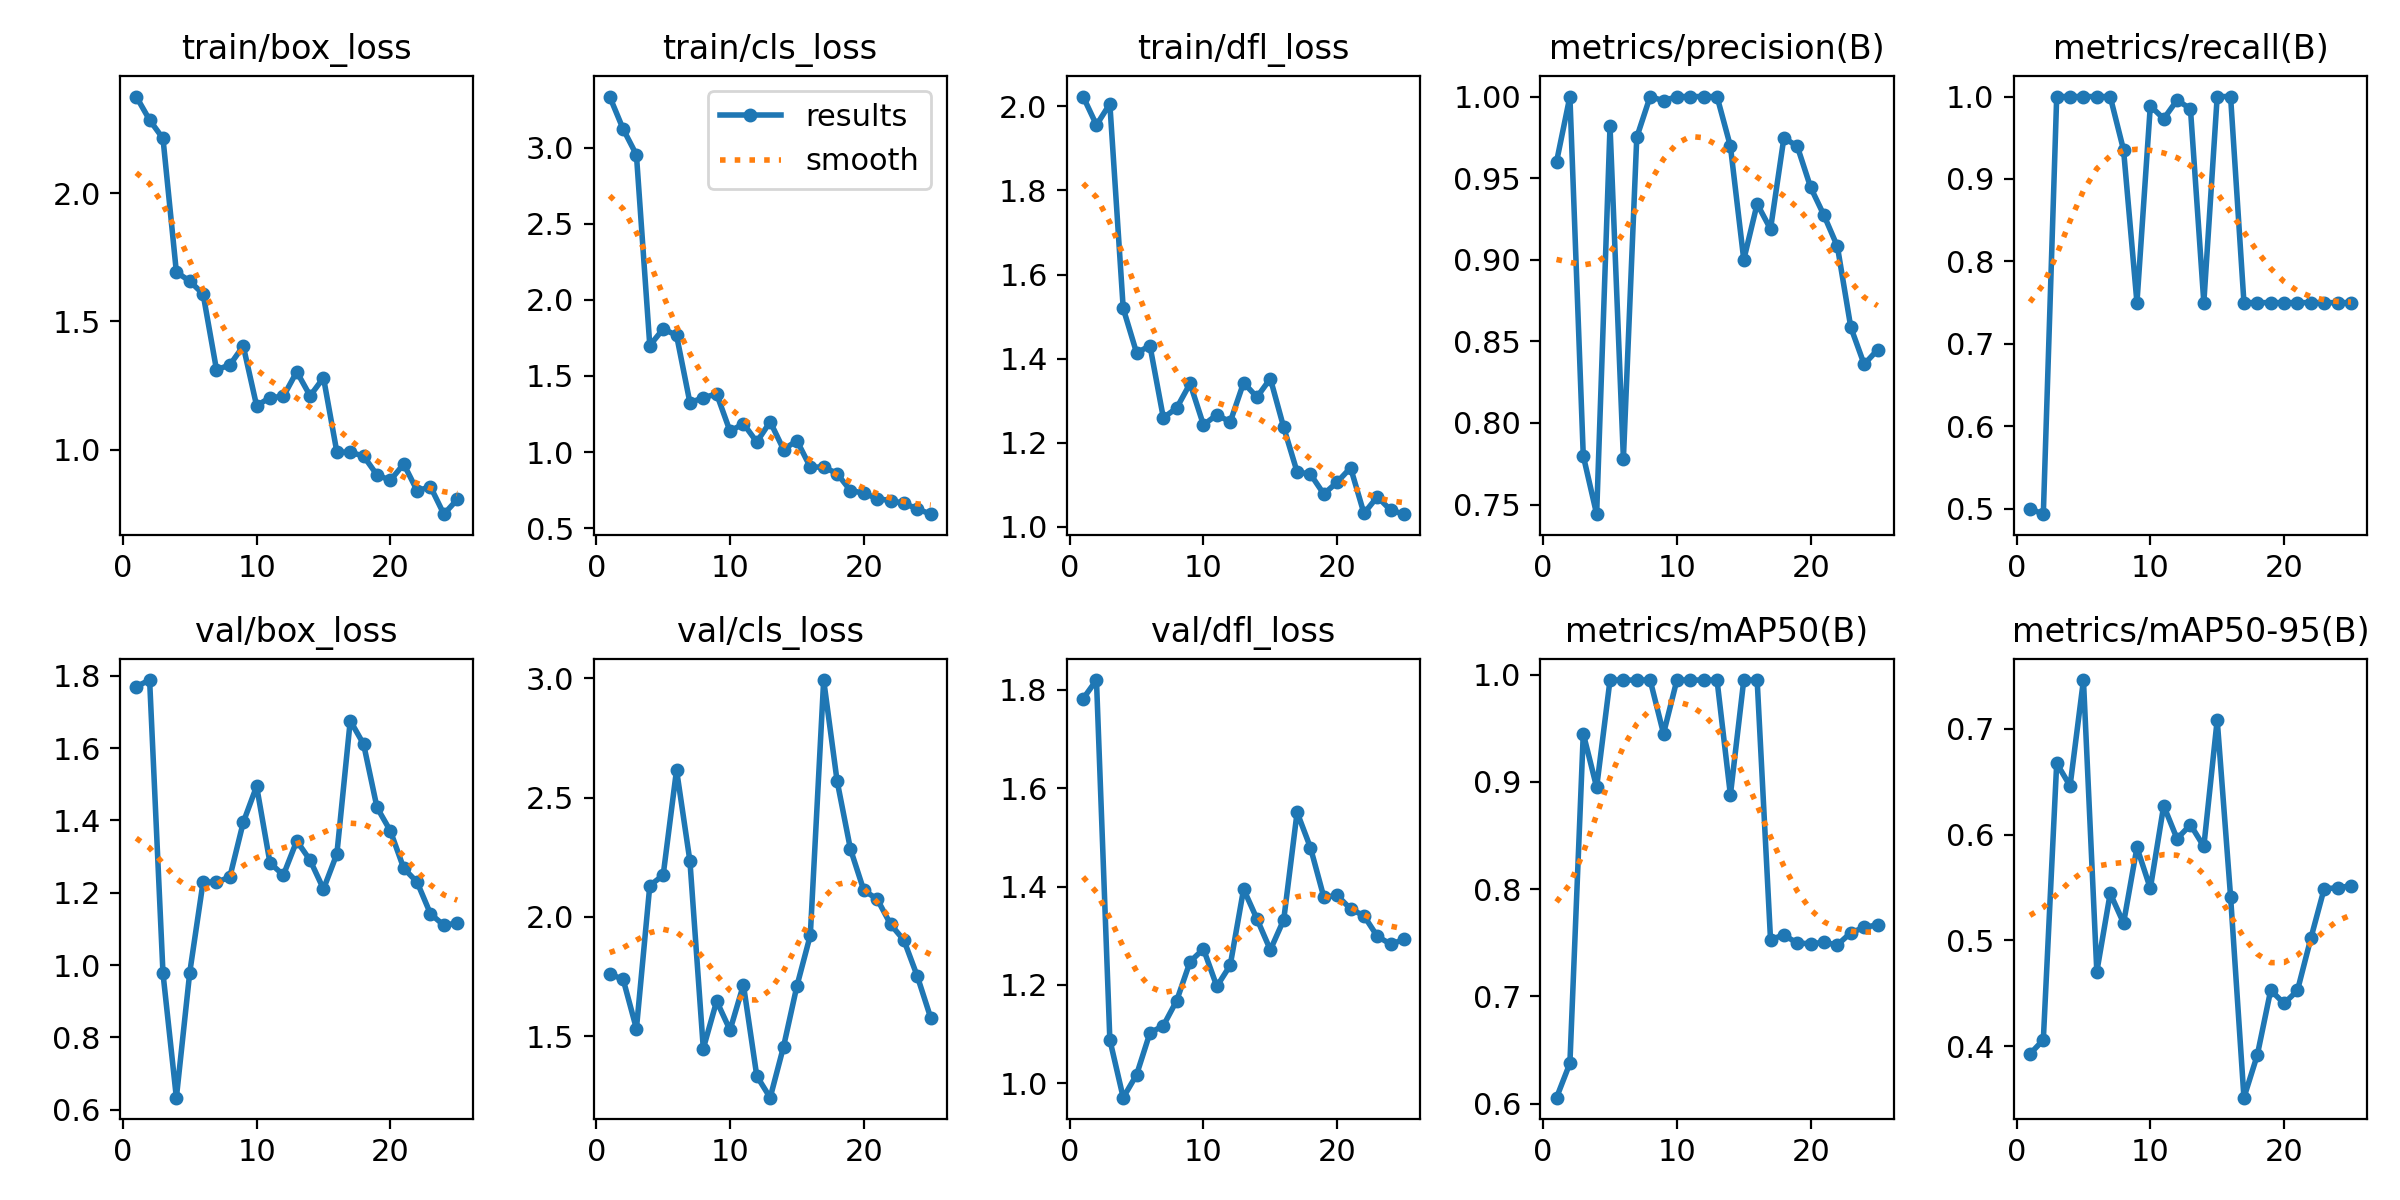

In [12]:
%cd {HOME}
from IPython.display import Image

Image(filename=f'{HOME}/runs/detect/train3/results.png', width=600)

/content


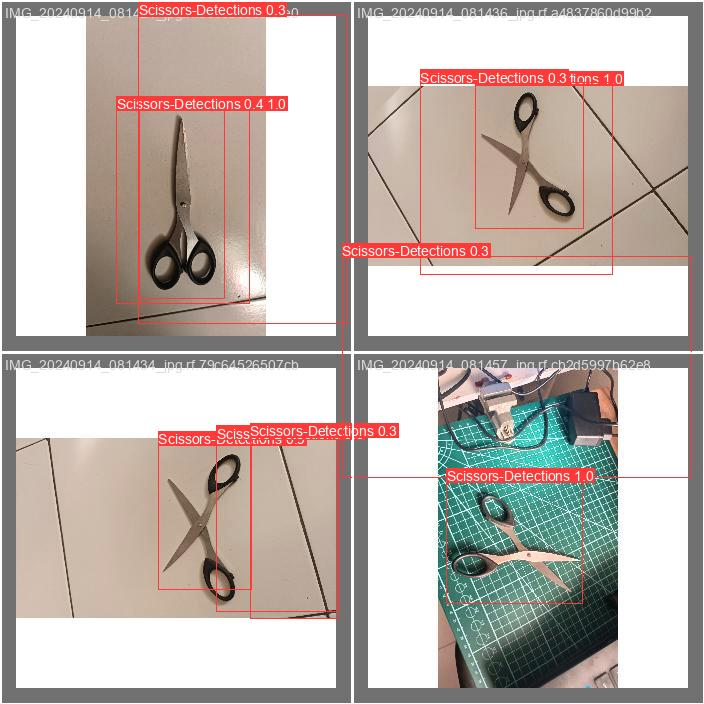

In [14]:
%cd {HOME}
from IPython.display import Image

Image(filename=f'{HOME}/runs/detect/train3/val_batch0_pred.jpg', width=600)

- Check mAP on Validation Dataset

In [16]:
%cd {HOME}

!yolo task=detect mode=val model={HOME}/runs/detect/train3/weights/best.pt data={dataset.location}/data.yaml

/content
/usr/local/lib/python3.12/dist-packages/ultralytics/nn/tasks.py:567: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(file, map_location='cpu'), file

## Test inference on Custom Yolo V8 Model
- trained model located in `{HOME}/runs/detect/train/weights/best.pt`
- we will try to do inferencing using that model to detect test image in `{dataset.location}/test/images`

In [18]:
%cd {HOME}
!yolo task=detect mode=predict model={HOME}/runs/detect/train3/weights/best.pt conf=0.4 source={dataset.location}/test/images save=True


/content
/usr/local/lib/python3.12/dist-packages/ultralytics/nn/tasks.py:567: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(file, map_location='cpu'), file

- Above command will generating detected image that located in `/content/runs/detect/`
- Show the detection image result using script below

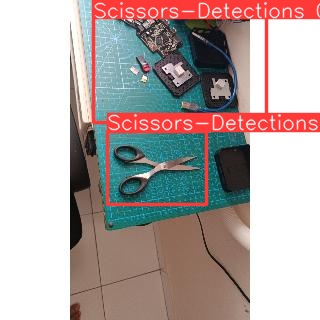

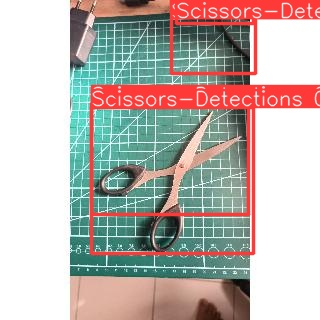

In [19]:
import glob
from IPython.display import Image, display

# Define the base path where the folders are located
base_path = '/content/runs/detect/'

# List all directories that start with 'predict' in the base path
subfolders = [os.path.join(base_path, d) for d in os.listdir(base_path)
              if os.path.isdir(os.path.join(base_path, d)) and d.startswith('predict')]

# Find the latest folder by modification time
latest_folder = max(subfolders, key=os.path.getmtime)

image_paths = glob.glob(f'{latest_folder}/*.jpg')[:3]

# Display each image
for image_path in image_paths:
    display(Image(filename=image_path, width=320))
    print("\n")

## Export to ONNX
- To use Pytorch (`.pt`) model generated by Utralytic in OpenCV DNN, we will need to convert that into `ONNX` format

In [21]:
# Export the model
from ultralytics import YOLO

model = YOLO(HOME + "/runs/detect/train3/weights/best.pt")  # Load a model
model.export(format="onnx", opset=12, imgsz=[320, 320])

Ultralytics YOLOv8.0.196 🚀 Python-3.12.13 torch-2.5.1+cu124 CPU (Intel Xeon 2.00GHz)
Model summary (fused): 168 layers, 11125971 parameters, 0 gradients, 28.4 GFLOPs

PyTorch: starting from '/content/runs/detect/train3/weights/best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 5, 2100) (21.4 MB)
requirements: Ultralytics requirement ['onnx>=1.12.0'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 321.4 MB/s eta 0:00:00

requirements: AutoUpdate success ✅ 7.0s, installed 1 package: ['onnx>=1.12.0']
requirements: ⚠️ Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 12...
ONNX: export success ✅ 8.0s, saved as '/content/runs/detect/train3/weights/best.onnx' (42.5 MB)

Export complete (10.7s)
Results saved to /content/runs/detect/train3/weights
Predict:         yolo predict task=detect model=/content/runs/detect/train3/weights/best.onnx imgsz=320  
Validate:        yolo

'/content/runs/detect/train3/weights/best.onnx'

In [22]:
# Download Yolo Model.
from google.colab import files
import shutil

shutil.copy(HOME + "/runs/detect/train3/weights/best.onnx", HOME + "/yolov8.onnx")
files.download(HOME + "/yolov8.onnx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

________________________________________________________________________

# Source
- https://github.com/roboflow/notebooks/blob/main/notebooks/train-yolov8-object-detection-on-custom-dataset.ipynb